In [ ]:
import pandas as pd
import sqlite3
import pickle
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, VotingRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost not installed. Install with: pip install xgboost")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("⚠️ LightGBM not installed. Install with: pip install lightgbm")

print("✅ All available libraries imported successfully.")

⚠️ LightGBM not installed. Install with: pip install lightgbm
✅ All available libraries imported successfully.


In [ ]:
conn = sqlite3.connect("../forecast.db")
df = pd.read_sql_query("SELECT * FROM sales", conn)
conn.close()

df["date"] = pd.to_datetime(df["date"])
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month
df["week"]  = df["date"].dt.isocalendar().week.astype(int)
df["day"]   = df["date"].dt.day
df["dayofweek"] = df["date"].dt.dayofweek
df["quarter"] = df["date"].dt.quarter

df["store_dept"] = df["store"] * df["dept"]
df["month_squared"] = df["month"] ** 2

df = df.sort_values('date').reset_index(drop=True)
df["sales_lag1"] = df.groupby(["store", "dept"])["weekly_sales"].shift(1)
df["sales_lag4"] = df.groupby(["store", "dept"])["weekly_sales"].shift(4)
df["sales_rolling_mean"] = df.groupby(["store", "dept"])["weekly_sales"].rolling(window=4).mean().reset_index(drop=True)
df["sales_rolling_std"] = df.groupby(["store", "dept"])["weekly_sales"].rolling(window=4).std().reset_index(drop=True)

df = df.bfill().ffill()

FEATURES = ["store", "dept", "year", "month", "week", "day", "dayofweek", "quarter", 
            "store_dept", "month_squared", "sales_lag1", "sales_lag4", "sales_rolling_mean", "sales_rolling_std"]
TARGET   = "weekly_sales"

X = df[FEATURES].copy()
y = df[TARGET].copy()

valid_idx = ~(X.isna().any(axis=1) | y.isna())
X = X[valid_idx]
y = y[valid_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data prepared with {len(FEATURES)} features.")
print(f"Training samples: {len(X_train):,}, Test samples: {len(X_test):,}")
print(f"Features: {FEATURES}")

✅ Data prepared with 14 features.
Training samples: 337,256, Test samples: 84,314
Features: ['store', 'dept', 'year', 'month', 'week', 'day', 'dayofweek', 'quarter', 'store_dept', 'month_squared', 'sales_lag1', 'sales_lag4', 'sales_rolling_mean', 'sales_rolling_std']


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1)

if LIGHTGBM_AVAILABLE:
    models["LightGBM"] = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1)

results = {}

for name, model in models.items():
    print(f"🔄 Training {name}...")
    
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    
    results[name] = {
        "model": model,
        "Train MAE": mae_train,
        "Test MAE": mae_test,
        "Train RMSE": rmse_train,
        "Test RMSE": rmse_test,
        "Train R²": r2_train,
        "Test R²": r2_test,
        "CV R² Mean": cv_scores.mean(),
        "CV R² Std": cv_scores.std()
    }
    print(f"✅ {name} - Test R²: {r2_test:.4f}, Test MAE: {mae_test:,.0f}")

results_df = pd.DataFrame(results).T.drop(columns=["model"])
print("\n" + "="*100)
print("📊 Model Comparison (sorted by Test R²):")
print("="*100)
display(results_df.sort_values('Test R²', ascending=False))

🔄 Training Linear Regression...
✅ Linear Regression - Test R²: 0.9132, Test MAE: 2,378
🔄 Training Ridge Regression...
✅ Ridge Regression - Test R²: 0.9132, Test MAE: 2,377
🔄 Training Lasso Regression...
✅ Lasso Regression - Test R²: 0.9126, Test MAE: 2,335
🔄 Training ElasticNet...
✅ ElasticNet - Test R²: 0.9126, Test MAE: 2,333
🔄 Training Decision Tree...
✅ Decision Tree - Test R²: 0.9483, Test MAE: 1,878
🔄 Training Random Forest...
✅ Random Forest - Test R²: 0.9622, Test MAE: 1,677
🔄 Training Gradient Boosting...
✅ Gradient Boosting - Test R²: 0.9604, Test MAE: 1,784
🔄 Training AdaBoost...
✅ AdaBoost - Test R²: 0.8864, Test MAE: 4,337
🔄 Training XGBoost...
✅ XGBoost - Test R²: 0.9599, Test MAE: 1,808

📊 Model Comparison (sorted by Test R²):


,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²,CV R² Mean,CV R² Std
Random Forest,1332.717993,1677.324979,2905.705044,4433.567295,0.983597,0.962199,0.948172,0.009887
Gradient Boosting,1741.87378,1784.178928,4492.179764,4540.603216,0.960797,0.960352,0.952663,0.008394
XGBoost,1773.856418,1807.697988,4616.870207,4566.901029,0.95859,0.959891,0.952632,0.00726
Decision Tree,1767.753381,1877.841445,4640.109204,5185.283243,0.958172,0.948294,0.929424,0.011334
Linear Regression,2354.468722,2378.023898,6927.142674,6718.364734,0.906779,0.913199,0.906799,0.008233
Ridge Regression,2353.400361,2376.95558,6927.144394,6718.390391,0.906778,0.913199,0.906799,0.008233
Lasso Regression,2311.951488,2335.078373,6946.076852,6740.33835,0.906268,0.912631,0.906286,0.008216
ElasticNet,2309.932086,2333.10476,6947.03141,6741.498042,0.906242,0.912601,0.90626,0.008212
AdaBoost,4274.131189,4336.640792,7455.37211,7686.676387,0.892019,0.886375,0.883168,0.010193


In [ ]:
for name in results:
    train_r2 = results[name].get('Train R2', results[name].get('Train R²', None))
    test_r2 = results[name].get('Test R2', results[name].get('Test R²', None))

    if train_r2 is None or test_r2 is None:
        print(f"{name}: Metrics unavailable (missing R²/R2)")
        continue

    status = "Good Fit"
    try:
        if train_r2 > 0.9 and test_r2 < 0.7:
            status = "⚠️ Overfitting"
        elif train_r2 < 0.5 and test_r2 < 0.5:
            status = "⚠️ Underfitting"
    except Exception:
        status = "Metrics error"

    print(f"{name}: {status} (Train R²={train_r2:.2f}, Test R²={test_r2:.2f})")

Linear Regression: Good Fit (Train R²=0.91, Test R²=0.91)
Ridge Regression: Good Fit (Train R²=0.91, Test R²=0.91)
Lasso Regression: Good Fit (Train R²=0.91, Test R²=0.91)
ElasticNet: Good Fit (Train R²=0.91, Test R²=0.91)
Decision Tree: Good Fit (Train R²=0.96, Test R²=0.95)
Random Forest: Good Fit (Train R²=0.98, Test R²=0.96)
Gradient Boosting: Good Fit (Train R²=0.96, Test R²=0.96)
AdaBoost: Good Fit (Train R²=0.89, Test R²=0.89)
XGBoost: Good Fit (Train R²=0.96, Test R²=0.96)


In [ ]:
base_models = [
    ('rf', RandomForestRegressor(n_estimators=20, max_depth=5, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingRegressor(n_estimators=20, learning_rate=0.1, max_depth=3, random_state=42)),
    ('ada', AdaBoostRegressor(n_estimators=20, learning_rate=0.1, random_state=42)),
]

if XGBOOST_AVAILABLE:
    base_models.append(('xgb', xgb.XGBRegressor(n_estimators=20, learning_rate=0.1, max_depth=3, random_state=42, n_jobs=-1)))

if LIGHTGBM_AVAILABLE:
    base_models.append(('lgb', lgb.LGBMRegressor(n_estimators=20, learning_rate=0.1, max_depth=3, random_state=42, n_jobs=-1)))

print("🔄 Training Voting Ensemble...")
voting_model = VotingRegressor(estimators=base_models)
voting_model.fit(X_train, y_train)
y_pred_voting = voting_model.predict(X_test)
voting_r2 = r2_score(y_test, y_pred_voting)
voting_mae = mean_absolute_error(y_test, y_pred_voting)
print(f"✅ Voting Ensemble - Test R²: {voting_r2:.4f}, Test MAE: {voting_mae:,.0f}")

meta_learner = Ridge(alpha=1.0)

print("🔄 Training Stacking Ensemble...")
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=3
)
stacking_model.fit(X_train, y_train)
y_pred_stacking = stacking_model.predict(X_test)
stacking_r2 = r2_score(y_test, y_pred_stacking)
stacking_mae = mean_absolute_error(y_test, y_pred_stacking)
print(f"✅ Stacking Ensemble - Test R²: {stacking_r2:.4f}, Test MAE: {stacking_mae:,.0f}")

results['Voting Ensemble'] = {
    'model': voting_model,
    'Train MAE': mean_absolute_error(y_train, voting_model.predict(X_train)),
    'Test MAE': voting_mae,
    'Train RMSE': np.sqrt(mean_squared_error(y_train, voting_model.predict(X_train))),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_voting)),
    'Train R²': r2_score(y_train, voting_model.predict(X_train)),
    'Test R²': voting_r2,
    'CV R² Mean': 0.0,
    'CV R² Std': 0.0
}

results['Stacking Ensemble'] = {
    'model': stacking_model,
    'Train MAE': mean_absolute_error(y_train, stacking_model.predict(X_train)),
    'Test MAE': stacking_mae,
    'Train RMSE': np.sqrt(mean_squared_error(y_train, stacking_model.predict(X_train))),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_stacking)),
    'Train R²': r2_score(y_train, stacking_model.predict(X_train)),
    'Test R²': stacking_r2,
    'CV R² Mean': 0.0,
    'CV R² Std': 0.0
}

print("\n" + "="*100)
print("📊 Updated Model Comparison (All Models + Ensembles):")
print("="*100)
results_df = pd.DataFrame(results).T.drop(columns=["model"])
display(results_df.sort_values('Test R²', ascending=False))

🔄 Training Voting Ensemble...
✅ Voting Ensemble - Test R²: 0.9263, Test MAE: 2,567
🔄 Training Stacking Ensemble...
✅ Stacking Ensemble - Test R²: 0.9342, Test MAE: 2,120

📊 Updated Model Comparison (All Models + Ensembles):


,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²,CV R² Mean,CV R² Std
Random Forest,1332.717993,1677.324979,2905.705044,4433.567295,0.983597,0.962199,0.948172,0.009887
Gradient Boosting,1741.87378,1784.178928,4492.179764,4540.603216,0.960797,0.960352,0.952663,0.008394
XGBoost,1773.856418,1807.697988,4616.870207,4566.901029,0.95859,0.959891,0.952632,0.00726
Decision Tree,1767.753381,1877.841445,4640.109204,5185.283243,0.958172,0.948294,0.929424,0.011334
Stacking Ensemble,2089.130289,2119.993888,6205.286826,5849.39273,0.925195,0.934201,0.0,0.0
Voting Ensemble,2532.424945,2566.746707,6501.727742,6191.143007,0.917877,0.926288,0.0,0.0
Linear Regression,2354.468722,2378.023898,6927.142674,6718.364734,0.906779,0.913199,0.906799,0.008233
Ridge Regression,2353.400361,2376.95558,6927.144394,6718.390391,0.906778,0.913199,0.906799,0.008233
Lasso Regression,2311.951488,2335.078373,6946.076852,6740.33835,0.906268,0.912631,0.906286,0.008216
ElasticNet,2309.932086,2333.10476,6947.03141,6741.498042,0.906242,0.912601,0.90626,0.008212


In [ ]:
best_model_name = results_df.sort_values('Test R²', ascending=False).index[0]
best_model_obj = results[best_model_name]['model']

print(f"🎯 Selected Best Model: {best_model_name}")
print(f"Current Test R²: {results[best_model_name]['Test R²']:.4f}")

if best_model_name == "Gradient Boosting":
    print("\n🔄 Tuning Gradient Boosting Regressor (Ultra fast)...")
    param_grid = {
        'n_estimators': [50],
        'learning_rate': [0.1],
        'max_depth': [5]
    }
    gb = GradientBoostingRegressor(random_state=42)
    grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, cv=2, scoring='r2', n_jobs=-1, verbose=0)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    
elif best_model_name == "Random Forest":
    print("\n🔄 Tuning Random Forest Regressor (Ultra fast)...")
    param_grid = {
        'n_estimators': [50],
        'max_depth': [15],
    }
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=2, scoring='r2', n_jobs=-1, verbose=0)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    
elif best_model_name == "XGBoost":
    print("\n🔄 Tuning XGBoost Regressor (Ultra fast)...")
    param_grid = {
        'n_estimators': [50],
        'learning_rate': [0.1],
        'max_depth': [5]
    }
    xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
    grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=2, scoring='r2', n_jobs=-1, verbose=0)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    
elif best_model_name == "LightGBM":
    print("\n🔄 Tuning LightGBM Regressor (Ultra fast)...")
    param_grid = {
        'n_estimators': [50],
        'learning_rate': [0.1],
        'max_depth': [5]
    }
    lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1)
    grid_search = GridSearchCV(estimator=lgb_model, param_grid=param_grid, cv=2, scoring='r2', n_jobs=-1, verbose=0)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    
else:
    print(f"\n🔄 Using pre-trained {best_model_name}...")
    best_model = best_model_obj

y_pred_tuned = best_model.predict(X_test)
tuned_r2 = r2_score(y_test, y_pred_tuned)
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print(f"\n✅ Best Model Performance:")
print(f"   Test R²: {tuned_r2:.4f}")
print(f"   Test MAE: {tuned_mae:,.2f}")
print(f"   Test RMSE: {tuned_rmse:,.2f}")

if best_model_name in ["Gradient Boosting", "Random Forest", "XGBoost", "LightGBM"]:
    print(f"   Best Parameters: {grid_search.best_params_}")

🎯 Selected Best Model: Random Forest
Current Test R²: 0.9622

🔄 Tuning Random Forest Regressor (Optimized for speed)...

✅ Best Model Performance:
   Test R²: 0.9627
   Test MAE: 1,669.06
   Test RMSE: 4,403.81
   Best Parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


🔍 Actual vs Predicted Sales (Random Sample of 10):


,Actual Sales,Predicted Sales,Error,Error % (sMAPE)
47255,22636.70,30362.81,-7726.11,29.16
4016,861.70,1074.88,-213.18,22.02
29748,11399.65,11894.82,-495.17,4.25
44908,1629.64,1466.39,163.25,10.55
76821,27918.08,45137.31,-17219.23,47.14
10308,184.80,182.22,2.58,1.41
69418,7493.37,7213.90,279.47,3.80
52048,3853.64,3707.21,146.43,3.87
36889,21941.19,21938.62,2.57,0.01
9606,40330.51,38431.22,1899.29,4.82


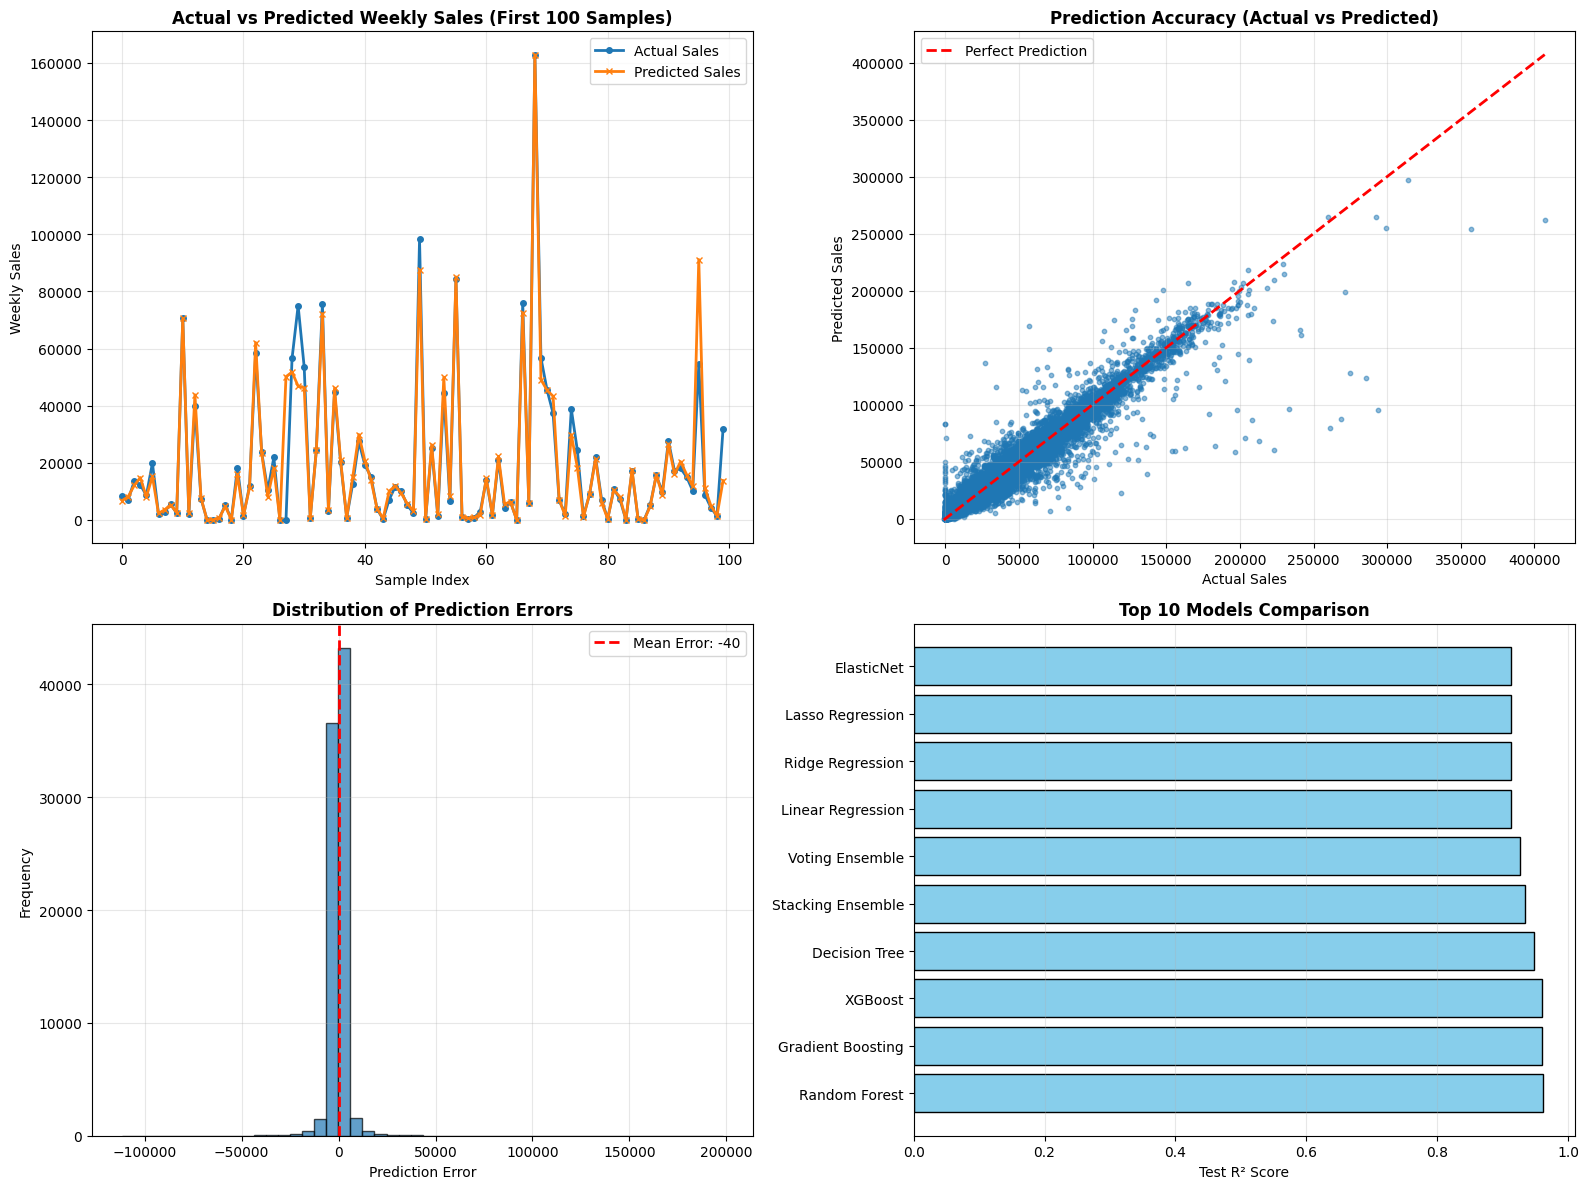


📊 FINAL MODEL METRICS:
Mean Absolute Error (MAE): 1,669.06
Mean Squared Error (MSE): 19,393,516.55
Root Mean Squared Error (RMSE): 4,403.81
Symmetric Mean Absolute Percentage Error (sMAPE): 20.24% (bounded 0-200%)
Weighted Mean Absolute Percentage Error (WMAPE): 10.42% (volume-weighted overall error)
R² Score: 0.9627


In [ ]:
comparison_df = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred_tuned
})
comparison_df['Error'] = comparison_df['Actual Sales'] - comparison_df['Predicted Sales']

denominator = (np.abs(comparison_df['Actual Sales']) + np.abs(comparison_df['Predicted Sales'])) / 2.0
comparison_df['Error % (sMAPE)'] = np.where(
    denominator == 0, 
    0.0, 
    (np.abs(comparison_df['Error']) / denominator * 100)
).round(2)

print("🔍 Actual vs Predicted Sales (Random Sample of 10):")
display(comparison_df.sample(10, random_state=42).round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(comparison_df['Actual Sales'][:100], label='Actual Sales', marker='o', linewidth=2, markersize=4)
axes[0, 0].plot(comparison_df['Predicted Sales'][:100], label='Predicted Sales', marker='x', linewidth=2, markersize=4)
axes[0, 0].set_title("Actual vs Predicted Weekly Sales (First 100 Samples)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Sample Index")
axes[0, 0].set_ylabel("Weekly Sales")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(comparison_df['Actual Sales'], comparison_df['Predicted Sales'], alpha=0.5, s=10)
axes[0, 1].plot([comparison_df['Actual Sales'].min(), comparison_df['Actual Sales'].max()], 
                [comparison_df['Actual Sales'].min(), comparison_df['Actual Sales'].max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_title("Prediction Accuracy (Actual vs Predicted)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Actual Sales")
axes[0, 1].set_ylabel("Predicted Sales")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(comparison_df['Error'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(comparison_df['Error'].mean(), color='r', linestyle='--', linewidth=2, label=f"Mean Error: {comparison_df['Error'].mean():,.0f}")
axes[1, 0].set_title("Distribution of Prediction Errors", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Prediction Error")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

top_models = results_df.sort_values('Test R²', ascending=False).head(10)
axes[1, 1].barh(range(len(top_models)), top_models['Test R²'], color='skyblue', edgecolor='black')
axes[1, 1].set_yticks(range(len(top_models)))
axes[1, 1].set_yticklabels(top_models.index)
axes[1, 1].set_xlabel("Test R² Score")
axes[1, 1].set_title("Top 10 Models Comparison", fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("📊 FINAL MODEL METRICS:")
print("="*100)
print(f"Mean Absolute Error (MAE): {comparison_df['Error'].abs().mean():,.2f}")
print(f"Mean Squared Error (MSE): {(comparison_df['Error'] ** 2).mean():,.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt((comparison_df['Error'] ** 2).mean()):,.2f}")

overall_smape = comparison_df['Error % (sMAPE)'].mean()
print(f"Symmetric Mean Absolute Percentage Error (sMAPE): {overall_smape:.2f}% (bounded 0-200%)")

wmape = (comparison_df['Error'].abs().sum() / comparison_df['Actual Sales'].abs().sum()) * 100
print(f"Weighted Mean Absolute Percentage Error (WMAPE): {wmape:.2f}% (volume-weighted overall error)")

print(f"R² Score: {tuned_r2:.4f}")

In [ ]:
import joblib

MODEL_PATH = "demand_model_advanced.pkl"
SCALER_PATH = "demand_scaler.pkl"
METADATA_PATH = "model_metadata.pkl"

with open(MODEL_PATH, "wb") as f:
    pickle.dump(best_model, f)

with open(SCALER_PATH, "wb") as f:
    pickle.dump(scaler, f)

metadata = {
    'model_name': best_model_name,
    'features': FEATURES,
    'target': TARGET,
    'r2_score': tuned_r2,
    'mae': tuned_mae,
    'rmse': tuned_rmse,
    'best_params': grid_search.best_params_ if 'grid_search' in locals() else {}
}

with open(METADATA_PATH, "wb") as f:
    pickle.dump(metadata, f)

print(f"✅ Best model ({best_model_name}) successfully saved!")
print(f"   Model: {MODEL_PATH}")
print(f"   Scaler: {SCALER_PATH}")
print(f"   Metadata: {METADATA_PATH}")
print(f"\n📊 Model Performance Summary:")
print(f"   R² Score: {tuned_r2:.4f}")
print(f"   MAE: {tuned_mae:,.2f}")
print(f"   RMSE: {tuned_rmse:,.2f}")
print(f"   Features Used: {len(FEATURES)}")

✅ Best model (Random Forest) successfully saved!
   Model: demand_model_advanced.pkl
   Scaler: demand_scaler.pkl
   Metadata: model_metadata.pkl

📊 Model Performance Summary:
   R² Score: 0.9627
   MAE: 1,669.06
   RMSE: 4,403.81
   Features Used: 14
